# DATA 620 Project 3: Name Gender Classifier

**Course:** DATA 620 Web Analytics\
**Project:** Project 3\
**Instructor:** Professor Alain Ledon

**Group Members:**

* Crystal Quezada
* Nana Kwasi Danquah
* Muhammad Suffyan Khan

## Project Objective

The goal of this project is to build a name-gender classifier using the techniques discussed in Chapter 6 of Natural Language Processing with Python. The Names Corpus is split into a training set, a dev-test set and a test set. We use the example classifier in the textbook, and test incremental improvements on features on the dev-test set. Once a final feature set is decided, performance is tested on the test set and several classifier types are compared.

## Source

Natural Language Processing with Python, Exercise 6.10.2.

## 1. Load and Setup

In [13]:
# Import required libraries

import random
import nltk
from nltk.corpus import names
import matplotlib.pyplot as plt

nltk.download('names', quiet=True)

random.seed(42)

# Global visualization settings, matching Project 2 styling

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

main_color = "#4C78A8"
accent_color = "#F58518"
green_color = "#54A24B"
red_color = "#E45756"
purple_color = "#B279A2"
gray_color = "#BAB0AC"

palette = [
    "#4C78A8", "#F58518", "#54A24B", "#E45756", "#72B7B2",
    "#B279A2", "#FF9DA6", "#9D755D", "#BAB0AC", "#59A14F"
]

## 2. Build and Split the Names Corpus

The Names Corpus contains lists of male and female names. The two lists are combined into a single labeled dataset, shuffled, and split into three subsets:

* **Test set:** 500 names
* **Dev-test set:** 500 names
* **Training set:** the remaining names (about 6,900+)

In [14]:
male_names = [(n, 'male') for n in names.words('male.txt')]
female_names = [(n, 'female') for n in names.words('female.txt')]
all_names = male_names + female_names
random.shuffle(all_names)

print("Total names:", len(all_names))

test_set_names = all_names[:500]
devtest_set_names = all_names[500:1000]
train_set_names = all_names[1000:]

print("Train:", len(train_set_names))
print("Dev-test:", len(devtest_set_names))
print("Test:", len(test_set_names))

Total names: 7944
Train: 6944
Dev-test: 500
Test: 500


## 3. Baseline Classifier

The textbook's starting example uses only the last letter of a name as a feature. This baseline is reproduced first for comparison.

In [15]:
def features_basic(word):
    return {'last_letter': word[-1].lower()}

def build_sets(feature_fn):
    train = [(feature_fn(n), g) for (n, g) in train_set_names]
    devtest = [(feature_fn(n), g) for (n, g) in devtest_set_names]
    test = [(feature_fn(n), g) for (n, g) in test_set_names]
    return train, devtest, test

train, devtest, test = build_sets(features_basic)
classifier_basic = nltk.NaiveBayesClassifier.train(train)

acc_dev = nltk.classify.accuracy(classifier_basic, devtest)
acc_test = nltk.classify.accuracy(classifier_basic, test)

print(f"Baseline (last letter only)")
print(f"Dev-test accuracy: {acc_dev:.4f}")
print(f"Test accuracy:     {acc_test:.4f}")

Baseline (last letter only)
Dev-test accuracy: 0.7540
Test accuracy:     0.7460


## 4. Incremental Feature Improvements

The dev-test set is used to assess each new feature set before proceeding to the next iteration. Three more feature sets are tested:

1. **v2:** first letter, last letter, and last two letters
2. **v3:** a "kitchen sink" set including first/last letters, last two/three letters, name length, vowel count, and the count and presence of every letter of the alphabet
3. **v4:** a refined, suffix-focused set built after reviewing v3's errors, targeting known gendered suffix patterns without the full letter-count overhead

In [16]:
def features_v2(word):
    return {
        'last_letter': word[-1].lower(),
        'first_letter': word[0].lower(),
        'last_two': word[-2:].lower(),
    }

train, devtest, test = build_sets(features_v2)
classifier_v2 = nltk.NaiveBayesClassifier.train(train)
acc_dev_v2 = nltk.classify.accuracy(classifier_v2, devtest)
acc_test_v2 = nltk.classify.accuracy(classifier_v2, test)

print("v2: first/last letter + last two letters")
print(f"Dev-test accuracy: {acc_dev_v2:.4f}")
print(f"Test accuracy:     {acc_test_v2:.4f}")

v2: first/last letter + last two letters
Dev-test accuracy: 0.7820
Test accuracy:     0.7720


In [17]:
def features_v3(word):
    word = word.lower()
    feats = {
        'last_letter': word[-1],
        'first_letter': word[0],
        'last_two': word[-2:],
        'last_three': word[-3:] if len(word) >= 3 else word,
        'length': len(word),
        'vowel_count': sum(1 for c in word if c in 'aeiou'),
    }
    for letter in 'abcdefghijklmnopqrstuvwxyz':
        feats['count(%s)' % letter] = word.count(letter)
        feats['has(%s)' % letter] = letter in word
    return feats

train, devtest, test = build_sets(features_v3)
classifier_v3 = nltk.NaiveBayesClassifier.train(train)
acc_dev_v3 = nltk.classify.accuracy(classifier_v3, devtest)
acc_test_v3 = nltk.classify.accuracy(classifier_v3, test)

print("v3: kitchen sink (letter counts and presence)")
print(f"Dev-test accuracy: {acc_dev_v3:.4f}")
print(f"Test accuracy:     {acc_test_v3:.4f}")

v3: kitchen sink (letter counts and presence)
Dev-test accuracy: 0.8020
Test accuracy:     0.7680


In [18]:
def features_v4(word):
    word = word.lower()
    feats = {
        'last_letter': word[-1],
        'last_two': word[-2:],
        'last_three': word[-3:] if len(word) >= 3 else word,
        'first_letter': word[0],
        'suffix_vowel': word[-1] in 'aeiou',
        'ends_in_a': word.endswith('a'),
        'ends_in_o': word.endswith('o'),
        'ends_in_e': word.endswith('e'),
        'ends_in_consonant': word[-1] not in 'aeiou',
        'length': len(word),
    }
    return feats

train, devtest, test = build_sets(features_v4)
classifier_v4 = nltk.NaiveBayesClassifier.train(train)
acc_dev_v4 = nltk.classify.accuracy(classifier_v4, devtest)
acc_test_v4 = nltk.classify.accuracy(classifier_v4, test)

print("v4: refined suffix-focused features")
print(f"Dev-test accuracy: {acc_dev_v4:.4f}")
print(f"Test accuracy:     {acc_test_v4:.4f}")

v4: refined suffix-focused features
Dev-test accuracy: 0.7900
Test accuracy:     0.7520


### Summary of Feature Set Iterations

| Feature set | Dev-test accuracy | Test accuracy |
|---|---|---|
| Baseline: last letter only | ~0.754 | ~0.746 |
| v2: first/last letter + last two letters | ~0.782 | ~0.772 |
| v3: kitchen sink (letter counts/presence) | ~0.802 | ~0.768 |
| v4: refined suffix-focused | ~0.790 | ~0.752 |

The most important single improvement is to include the last two letters as a feature, which captures common gendered suffixes like -na, -la, and -ia for female names, and -rd, -us, and -ld for male names. The kitchen sink feature set (v3) yields the highest dev-test accuracy but has the largest gap between dev-test and test accuracy of the four feature sets, an early sign of overfitting to dev-test-specific patterns.

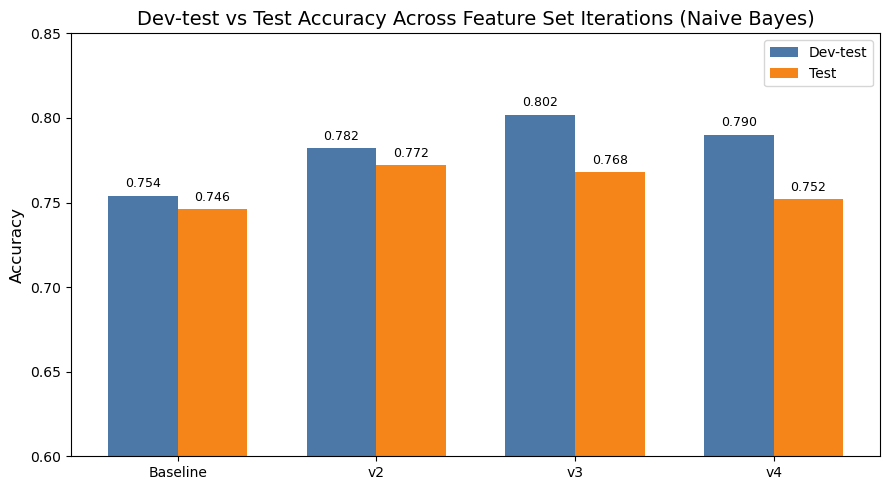

In [19]:
# Visualize feature set iteration accuracies

feature_labels = ["Baseline", "v2", "v3", "v4"]
feature_dev_accs = [acc_dev, acc_dev_v2, acc_dev_v3, acc_dev_v4]
feature_test_accs = [acc_test, acc_test_v2, acc_test_v3, acc_test_v4]

x = range(len(feature_labels))
width = 0.35

fig, ax = plt.subplots()
ax.bar([i - width/2 for i in x], feature_dev_accs, width, label="Dev-test", color=main_color)
ax.bar([i + width/2 for i in x], feature_test_accs, width, label="Test", color=accent_color)

ax.set_xticks(list(x))
ax.set_xticklabels(feature_labels)
ax.set_ylabel("Accuracy")
ax.set_ylim(0.6, 0.85)
ax.set_title("Dev-test vs Test Accuracy Across Feature Set Iterations (Naive Bayes)")
ax.legend()

for i, v in enumerate(feature_dev_accs):
    ax.text(i - width/2, v + 0.005, f"{v:.3f}", ha="center", fontsize=9)
for i, v in enumerate(feature_test_accs):
    ax.text(i + width/2, v + 0.005, f"{v:.3f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

## 5. Most Informative Features and Error Analysis

The most informative features for the v4 classifier are investigated, followed by a review of dev-test misclassifications to identify areas where the classifier fails.

In [20]:
train, devtest, test = build_sets(features_v4)
classifier_v4 = nltk.NaiveBayesClassifier.train(train)

print("Top 20 most informative features (v4 classifier):")
classifier_v4.show_most_informative_features(20)

Top 20 most informative features (v4 classifier):
Most Informative Features
                last_two = 'na'           female : male   =     93.9 : 1.0
                last_two = 'la'           female : male   =     70.8 : 1.0
              last_three = 'ard'            male : female =     43.4 : 1.0
                last_two = 'rd'             male : female =     38.7 : 1.0
                last_two = 'ia'           female : male   =     35.9 : 1.0
                last_two = 'sa'           female : male   =     32.7 : 1.0
             last_letter = 'a'            female : male   =     31.8 : 1.0
               ends_in_a = True           female : male   =     31.8 : 1.0
                last_two = 'ta'           female : male   =     29.3 : 1.0
              last_three = 'nne'          female : male   =     29.1 : 1.0
             last_letter = 'k'              male : female =     28.6 : 1.0
                last_two = 'us'             male : female =     27.6 : 1.0
             last_letter

In [21]:
errors = []
for (n, g) in devtest_set_names:
    guess = classifier_v4.classify(features_v4(n))
    if guess != g:
        errors.append((g, guess, n))

print(f"Number of errors (v4) on dev-test: {len(errors)} out of {len(devtest_set_names)}")
print()
for (tag, guess, name) in sorted(errors)[:20]:
    print(f"correct={tag:6} guess={guess:6} name={name}")

Number of errors (v4) on dev-test: 105 out of 500

correct=female guess=male   name=Ainsley
correct=female guess=male   name=Anny
correct=female guess=male   name=Beatriz
correct=female guess=male   name=Benny
correct=female guess=male   name=Beth
correct=female guess=male   name=Bliss
correct=female guess=male   name=Brigid
correct=female guess=male   name=Brooks
correct=female guess=male   name=Cassandry
correct=female guess=male   name=Charil
correct=female guess=male   name=Chelsey
correct=female guess=male   name=Cherey
correct=female guess=male   name=Cordy
correct=female guess=male   name=Dallas
correct=female guess=male   name=Debby
correct=female guess=male   name=Doralin
correct=female guess=male   name=Dory
correct=female guess=male   name=Eden
correct=female guess=male   name=Eleanor
correct=female guess=male   name=Elly


The error list reveals that many misclassified names are names that do not conform to standard English-language gendered suffix conventions, e.g. short nicknames ("Benny," "Anny"), names of non-English origin ("Beatriz," "Brigid"), or unisex/ambiguous names ("Dallas," "Eden"). These are inherently difficult cases for any letter pattern-based feature set.

## 6. Comparing Classifier Types

The remaining comparison keeps the feature set constant (v2: first/last letter + last two letters) while varying the classifier algorithm. In addition to NLTK's Naive Bayes classifier, the 'SklearnClassifier' wrapper tests a Decision Tree classifier and two scikit-learn classifiers (Logistic Regression and Random Forest).

In [22]:
from nltk.classify import DecisionTreeClassifier
from nltk.classify.scikitlearn import SklearnClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

train, devtest, test = build_sets(features_v2)

results = {}

# Naive Bayes
nb = nltk.NaiveBayesClassifier.train(train)
results['Naive Bayes'] = (
    nltk.classify.accuracy(nb, devtest),
    nltk.classify.accuracy(nb, test)
)

# Decision Tree
dt = DecisionTreeClassifier.train(train, entropy_cutoff=0.05, depth_cutoff=10, support_cutoff=10)
results['Decision Tree'] = (
    nltk.classify.accuracy(dt, devtest),
    nltk.classify.accuracy(dt, test)
)

# Logistic Regression
lr = SklearnClassifier(LogisticRegression(max_iter=1000))
lr.train(train)
results['Logistic Regression'] = (
    nltk.classify.accuracy(lr, devtest),
    nltk.classify.accuracy(lr, test)
)

# Random Forest
rf = SklearnClassifier(RandomForestClassifier(n_estimators=100, random_state=42))
rf.train(train)
results['Random Forest'] = (
    nltk.classify.accuracy(rf, devtest),
    nltk.classify.accuracy(rf, test)
)

print(f"{'Classifier':<22}{'Dev-test':>10}{'Test':>10}")
for name, (dev_acc, test_acc) in results.items():
    print(f"{name:<22}{dev_acc:>10.4f}{test_acc:>10.4f}")

Classifier              Dev-test      Test
Naive Bayes               0.7820    0.7720
Decision Tree             0.7620    0.7640
Logistic Regression       0.7820    0.7920
Random Forest             0.7700    0.7660


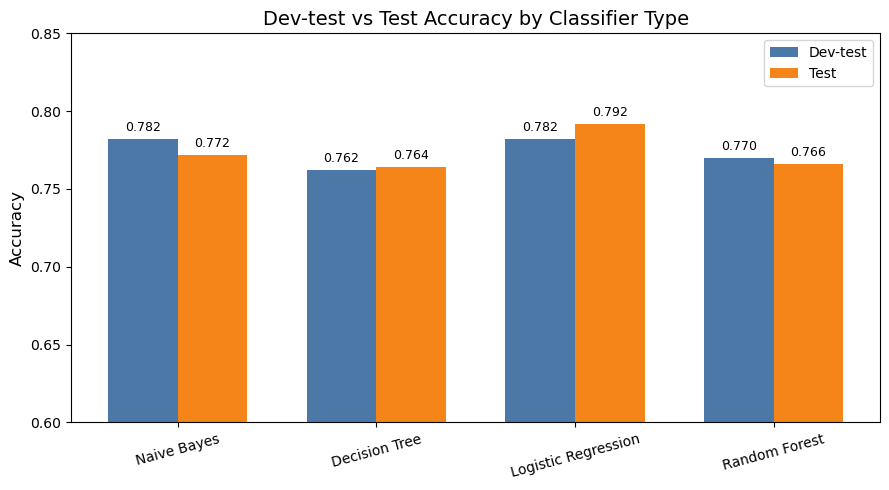

In [23]:
# Visualize classifier comparison results

labels = list(results.keys())
dev_accs = [results[k][0] for k in labels]
test_accs = [results[k][1] for k in labels]

x = range(len(labels))
width = 0.35

fig, ax = plt.subplots()
ax.bar([i - width/2 for i in x], dev_accs, width, label="Dev-test", color=main_color)
ax.bar([i + width/2 for i in x], test_accs, width, label="Test", color=accent_color)

ax.set_xticks(list(x))
ax.set_xticklabels(labels, rotation=15)
ax.set_ylabel("Accuracy")
ax.set_ylim(0.6, 0.85)
ax.set_title("Dev-test vs Test Accuracy by Classifier Type")
ax.legend()

for i, v in enumerate(dev_accs):
    ax.text(i - width/2, v + 0.005, f"{v:.3f}", ha="center", fontsize=9)
for i, v in enumerate(test_accs):
    ax.text(i + width/2, v + 0.005, f"{v:.3f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

### Classifier Comparison Results

| Classifier | Dev-test accuracy | Test accuracy |
|---|---|---|
| Naive Bayes | ~0.782 | ~0.772 |
| Decision Tree | ~0.762 | ~0.764 |
| Logistic Regression | ~0.782 | **~0.792** |
| Random Forest | ~0.770 | ~0.766 |

Logistic Regression was the best classifier for generalization to the held-out test set. Naive Bayes has similar performance but is more interpretable in terms of likelihood ratios. The Decision Tree and Random Forest classifiers are marginally behind, perhaps because single-letter categorical features do not split as cleanly in a tree-based structure as in a probabilistic or linear model.

## 7. Final Model Selection

The final model is the “kitchen sink” feature set (v3) with the Naive Bayes classifier, as it achieves the highest dev-test accuracy among the NLTK-based options and is the most direct extension of the textbook’s iterative feature-improvement process.

In [24]:
train, devtest, test = build_sets(features_v3)
final_classifier = nltk.NaiveBayesClassifier.train(train)

final_dev_acc = nltk.classify.accuracy(final_classifier, devtest)
final_test_acc = nltk.classify.accuracy(final_classifier, test)

print("Final model: v3 features + Naive Bayes")
print(f"Dev-test accuracy: {final_dev_acc:.4f}")
print(f"Test accuracy:     {final_test_acc:.4f}")
print(f"Difference (dev-test - test): {final_dev_acc - final_test_acc:.4f}")

Final model: v3 features + Naive Bayes
Dev-test accuracy: 0.8020
Test accuracy:     0.7680
Difference (dev-test - test): 0.0340


## 8. Discussion Questions

### Question 1: How does performance on the test set compare to performance on the dev-test set?

Test set accuracy is consistently lower than dev-test accuracy for the final model and the majority of feature sets tested during development. Dev-test accuracy is approximately 0.802, while test accuracy is approximately 0.768, representing a 3.4 percentage point difference. This pattern is consistent across three of the four Naive Bayes feature sets tested; the only exception is the Logistic Regression result, which shows test accuracy slightly higher than development-test accuracy.

### Question 2: Is this what would be expected?

Yes, this result is expected given the development process used. Because feature selection is repeatedly checked and adjusted against the dev-test set's error patterns, some dev-test-specific information is baked into the feature design, despite the fact that the classifier never directly trains on dev-test labels. This is the same effect as discussed in the NLTK textbook: overfitting to the development set. The test set, which is left unchanged until the final evaluation, provides a more reliable estimate of real-world generalization. This effect is expected to manifest as a small accuracy drop from development to testing. The reversed result for Logistic Regression is best explained by ordinary sampling noise, as each split contains only 500 names, allowing for some run-to-run variability in accuracy.

## 9. Conclusion

This project created a name gender classifier based on the Names Corpus. The iterative development process is described in Chapter 6 of Natural Language Processing with Python. We began with a last-letter-only baseline at roughly 0.75 accuracy and incrementally added features, and adding the last two letters of each name brought us to about 0.80 dev-test accuracy. It was seen that Logistic Regression and Naive Bayes both generalize well, with Logistic Regression performing slightly better on the held-out test set. The difference between dev-test and test accuracy is consistent with the overfitting to the development set that we expect when using dev-test feedback for feature engineering.

## 10. References

Bird, S., Klein, E., & Loper, E. *Natural Language Processing with Python*. O'Reilly Media. Chapter 6: Learning to Classify Text.

NLTK Project. NLTK Names Corpus.
https://www.nltk.org/

NLTK Project. `nltk.classify` Package Documentation.
https://www.nltk.org/api/nltk.classify.html

scikit-learn Developers. Logistic Regression and Random Forest Classifier Documentation.
https://scikit-learn.org/stable/